In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import scipy.stats as stats # Statistical functions


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression # Linear Regression model

from sklearn.metrics import r2_score # R-squared metric for regression evaluation

from sklearn.preprocessing import PowerTransformer # Transformer for power transforms (e.g., Yeo-Johnson, Box-Cox)


In [6]:
df = pd.read_csv('/content/concrete_data.csv')


In [7]:
df.head(1)


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99


In [8]:
df.shape


(1030, 9)

In [9]:
df.isnull().sum()


,0
Cement,0
Blast Furnace Slag,0
Fly Ash,0
Water,0
Superplasticizer,0
Coarse Aggregate,0
Fine Aggregate,0
Age,0
Strength,0


In [10]:
df.describe()


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [11]:
X = df.drop(columns=['Strength']) # Create feature matrix X by dropping the 'Strength' column
y = df.iloc[:,-1] # Create target vector y by selecting the last column ('Strength')


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


In [13]:
# Applying regression without any transformer
lr = LinearRegression() # Initialize a Linear Regression model
lr.fit(X_train, y_train) # Train the model on the training data
y_pred = lr.predict(X_test) # Make predictions on the test data
r2_score(y_test, y_pred) # Calculate the R-squared score to evaluate the model's performance


0.627553179231485

In [14]:
# Cross checking with cross val score
lr = LinearRegression() # Initialize another Linear Regression model
np.mean(cross_val_score(lr, X, y, scoring='r2')) # Perform cross-validation and calculate the mean R-squared score


np.float64(0.46099404916628606)

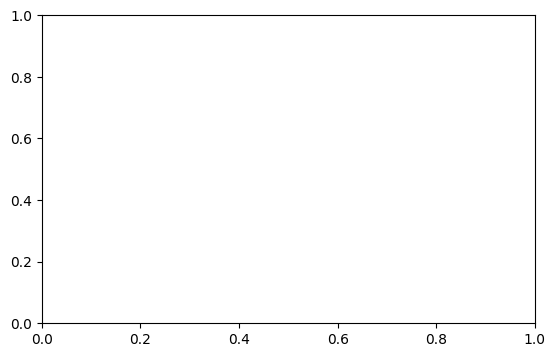

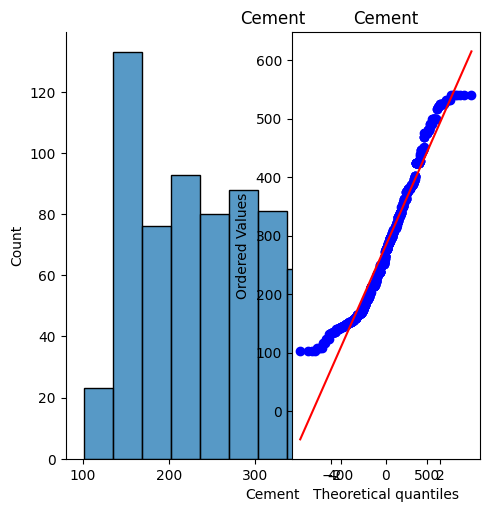

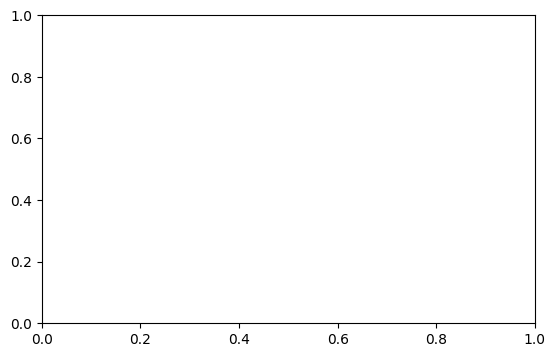

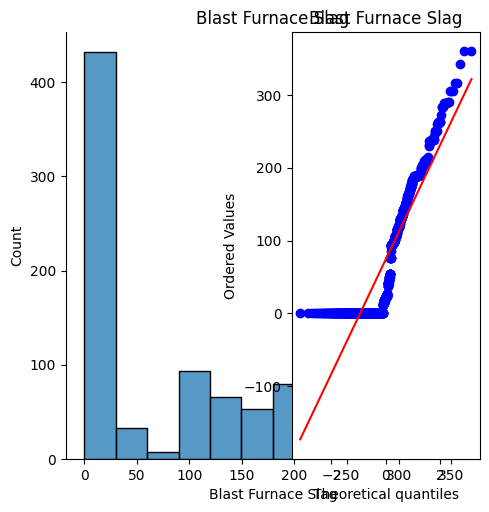

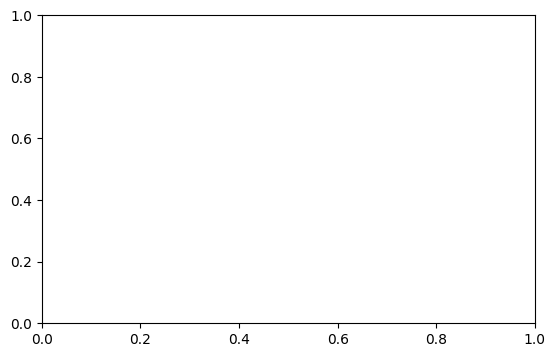

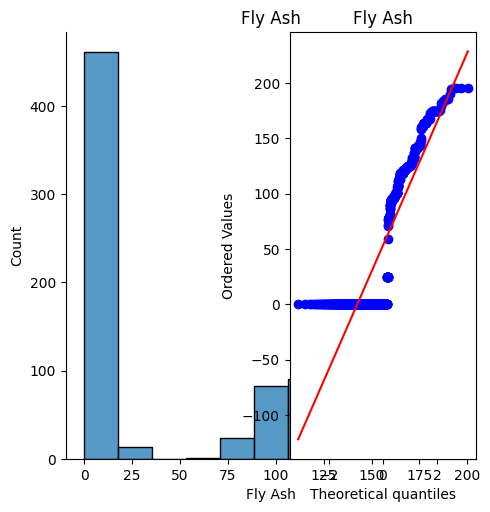

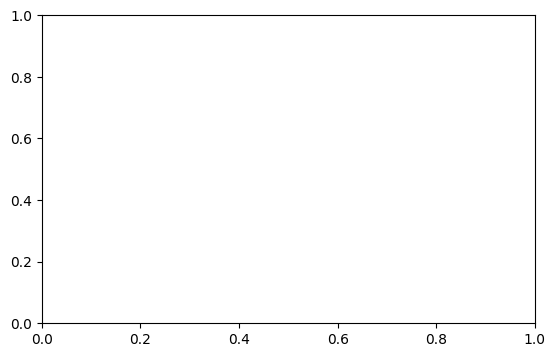

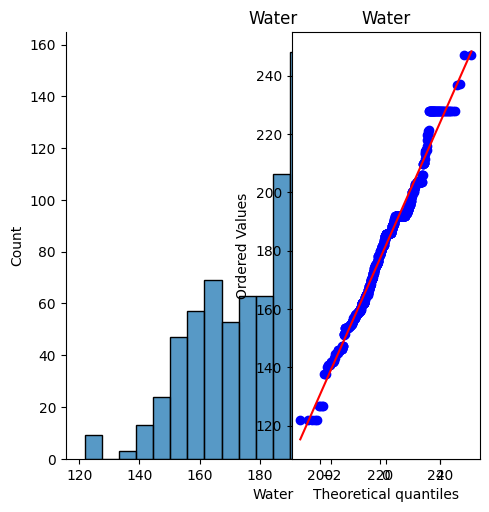

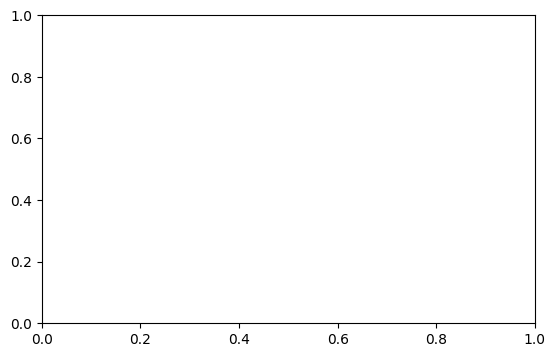

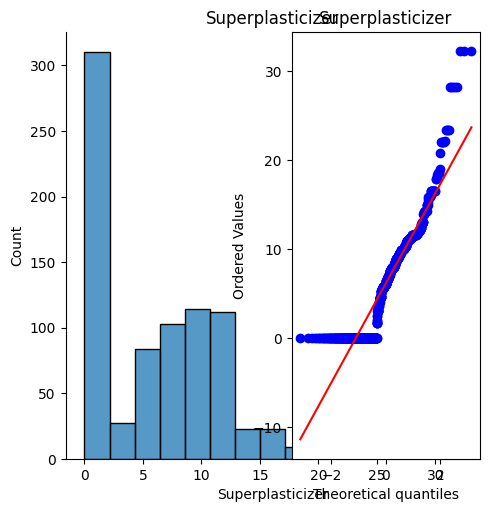

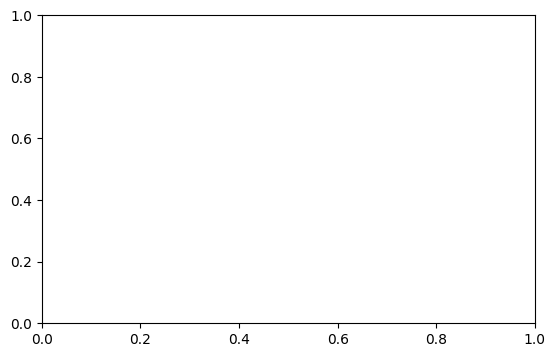

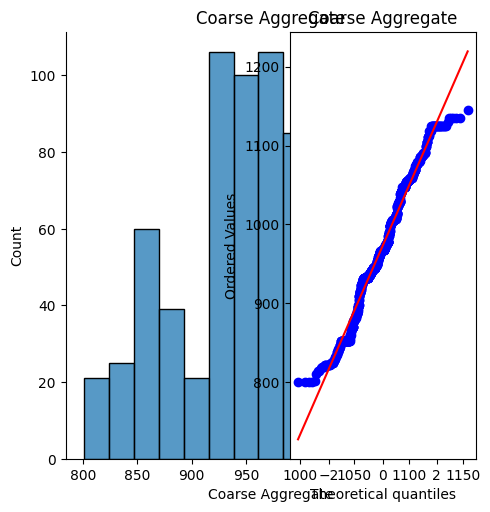

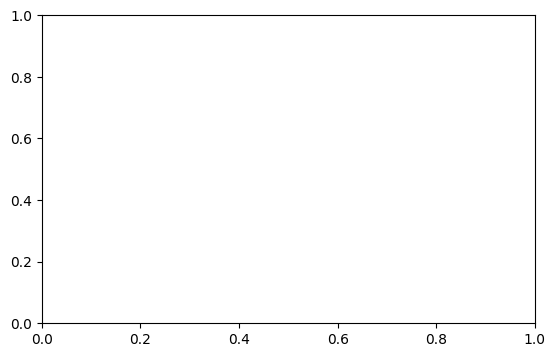

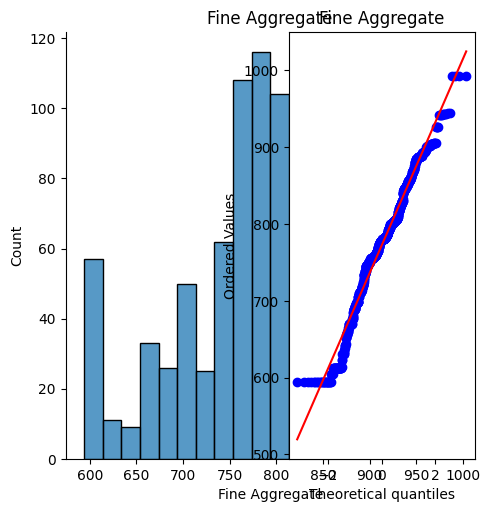

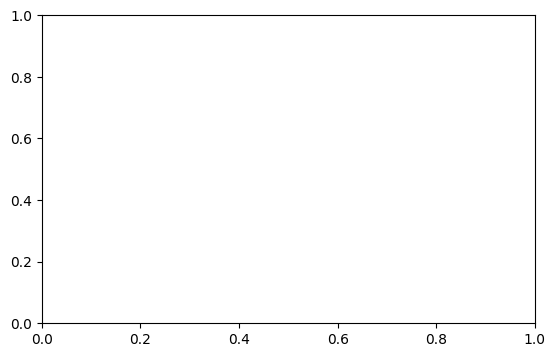

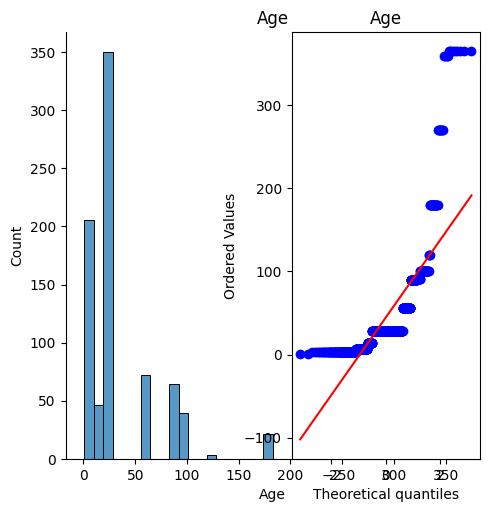

In [15]:
# Plotting the distplots without any transformation

for col in X.columns:
  plt.figure(figsize = (14, 4)) # Create a new figure for each column
  plt.subplot(121) # Create a subplot for the distribution plot
  sns.displot(X_train[col]) # Plot the distribution of the current feature
  plt.title(col) # Set the title of the distribution plot

  plt.subplot(122) # Create another subplot for the Q-Q plot
  stats.probplot(X_train[col], dist='norm', plot=plt) # Plot a Q-Q plot against a normal distribution
  plt.title(col) # Set the title of the Q-Q plot


In [16]:
plt.show() # Display the plots generated in the previous cell
